# Covariance matrix


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.covariance import shrunk_covariance

## Exercise 1: Understanding the relationship between data and covariance
The function `generate_data()` creates data from a mean vector and covariance matrix.
1. Visualize the data by plotting a scatter plot (`plt.scatter()`);
1. Visualize the data by plotting two histograms (`plt.hist()`), one for each feature, in separate plots or using `plt.subplots()`);
1. Inspect how the data (your two plots) change when changing the properties of the data (i.e., its mean and covariance).

In [2]:
def generate_data(N=300, cov=[[2, 1], [1, 2]], mean=[0, 5]):
    X = np.random.multivariate_normal(mean, cov, N)
    return X

In [3]:
np.random.seed(42) # ensures replicable results
X = generate_data()
Y = generate_data(N=300, cov=[[1, -0.5], [-0.5, 1]], mean=[2, 2])


(array([ 2.,  0.,  0.,  0.,  2.,  3.,  2.,  2.,  2.,  4.,  4., 11., 10.,
         7.,  7.,  8., 21., 18., 15., 14., 19., 12., 18., 14., 20., 14.,
        17.,  9.,  8.,  9.,  2., 10.,  4.,  4.,  3.,  2.,  1.,  1.,  0.,
         1.]),
 array([0.84477791, 1.04340077, 1.24202363, 1.44064648, 1.63926934,
        1.8378922 , 2.03651506, 2.23513791, 2.43376077, 2.63238363,
        2.83100649, 3.02962934, 3.2282522 , 3.42687506, 3.62549792,
        3.82412078, 4.02274363, 4.22136649, 4.41998935, 4.61861221,
        4.81723506, 5.01585792, 5.21448078, 5.41310364, 5.61172649,
        5.81034935, 6.00897221, 6.20759507, 6.40621792, 6.60484078,
        6.80346364, 7.0020865 , 7.20070935, 7.39933221, 7.59795507,
        7.79657793, 7.99520078, 8.19382364, 8.3924465 , 8.59106936,
        8.78969221]),
 <BarContainer object of 40 artists>)

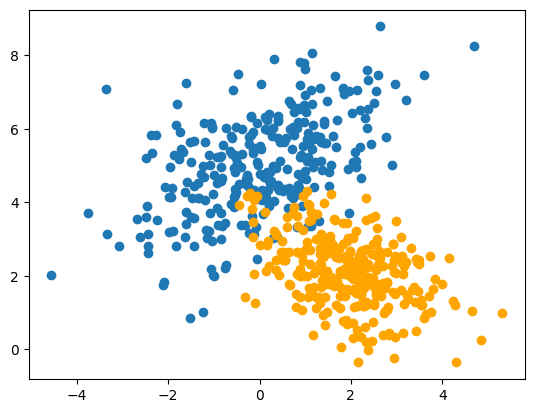

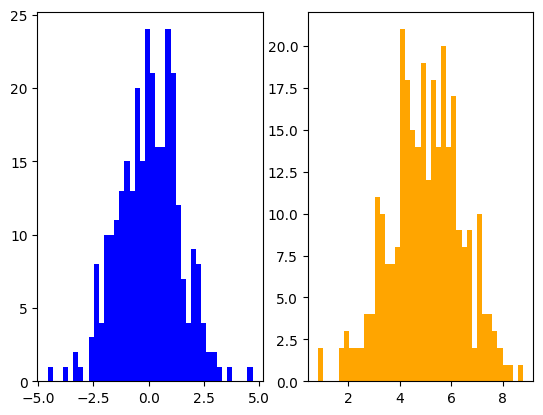

In [4]:
# Answer here
plt.scatter(X[:, 0], X[:, 1])
plt.scatter(Y[:, 0], Y[:, 1], color="orange")
fig, ax = plt.subplots(1, 2)
ax[0].hist(X[:, 0], bins=40, color="blue")
ax[1].hist(X[:, 1], bins=40, color="orange")


## Exercise 2: covariance estimator for n-dimensional data
The function `generate_covariance()` that generates a covariance matrix. The resulting covariance matrix is used with `generate_data()` to generate data.
1. Implement a function `estimate_covariance(X)` that calculates the covariance matrix for a given data set $\mathbf{X}\in\mathbb{R}^{N \times D}$ of $N$ examples by $D$ features.
1. Test, compare and validate your function with `np.cov` (read its documentation) and the true covariance matrix `cov_true`.
1. Visualize the three covariance matrices (e.g., `plt.imshow()`) using separate subplots (`plt.subplots()`). 

**Hint**: inspect the shape of your output using `var.shape` and compare it with your expectations for a desired input of $N \times D$.

In [5]:
def generate_covariance(D):
    tmp = np.random.randn(D, D)
    cov = np.dot(tmp, tmp.transpose()) 
    return cov

In [6]:
np.random.seed(42) # ensures replicable results
N = 200
D = 100
cov_true = generate_covariance(D)
X = generate_data(N, cov_true, np.zeros(D))

In [7]:
# Answer here
def estimate_covariance(X): # X in NxD dimensoins
    S = X.T @ X * 1/N
    return S
estimate = estimate_covariance(X)
print(estimate.shape == cov_true.shape)
print(estimate)
print(np.cov(X.T))
print(cov_true)


True
[[ 84.98532226 -15.08665044  24.48001032 ...  -4.2987522    5.3376737
   -5.29185836]
 [-15.08665044  87.73738134 -10.9403899  ...  21.57631261   4.35261035
   -0.7858676 ]
 [ 24.48001032 -10.9403899  118.36682058 ... -15.97641964   8.85646037
   -4.3502636 ]
 ...
 [ -4.2987522   21.57631261 -15.97641964 ...  91.02529829   3.29182673
    4.39594172]
 [  5.3376737    4.35261035   8.85646037 ...   3.29182673  84.91591294
   14.59284876]
 [ -5.29185836  -0.7858676   -4.3502636  ...   4.39594172  14.59284876
  117.55897758]]
[[ 84.95506649 -14.39865944  24.88096653 ...  -3.74564609   5.24720775
   -4.97908326]
 [-14.39865944  86.90258294 -11.45957863 ...  20.72487011   4.57037567
   -1.35662158]
 [ 24.88096653 -11.45957863 118.79270623 ... -16.40598973   8.97224885
   -4.57837936]
 ...
 [ -3.74564609  20.72487011 -16.40598973 ...  90.76048054   3.45576411
    3.99155135]
 [  5.24720775   4.57037567   8.97224885 ...   3.45576411  85.31254506
   14.75321733]
 [ -4.97908326  -1.35662158 

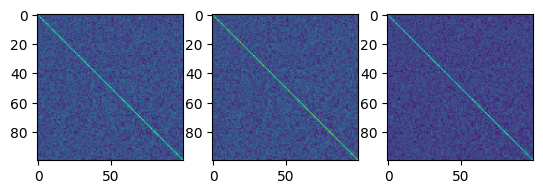

In [8]:
fig, axs = plt.subplots(1, 3)
axs[0].imshow(estimate)
axs[1].imshow(np.cov(X.T))
axs[2].imshow(cov_true)


## Exercise 3: eigenvectors of the covariance matrix
1. Calculate eigenvalues and eigenvectors of the true covariance matrix using `np.linalg.eig()`;
1. Visualize the data (`plt.scatter()`) and overlay the eigenvectors (`plt.plot()`).


In [9]:
np.random.seed(42) # ensures replicable results
D = 2
N = 500
cov_true = generate_covariance(D)
X = generate_data(N, cov_true, np.zeros(D))

(500, 2)
[[-0.99899602 -0.04479906]
 [ 0.04479906 -0.99899602]]
[0.2608582  2.74410415]


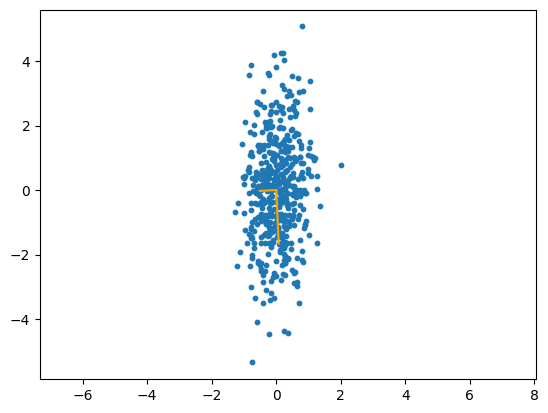

In [10]:
# Answer here
print(X.shape)
e_values, e_vectors = np.linalg.eig(cov_true)
print(e_vectors)
print(e_values)

# plt.xlim(-5, 5)
# plt.ylim(-5, 5)
plt.axis("equal")

plt.scatter(X[:, 0], X[:, 1], s=10)
plt.plot([0, e_vectors[0,0]*np.sqrt(e_values[0])], [0, e_vectors[0,1]*np.sqrt(e_values[0])], color="orange")
plt.plot([0, e_vectors[1,0]*np.sqrt(e_values[1])], [0, e_vectors[1,1]*np.sqrt(e_values[1])], color="orange")



## Exercise 4: eigenvalue spectrum for various sample sizes
For a fixed number of features $D = 100$, vary the number of samples $N$ and implement the following steps:
 1. Estimate the covariance matrix from the generated samples X;
 2. Calculate the eigenvalues of the covariance matrix;
 3. Sort the eigenvalues in descending order;
 4. Plot the eigenvalues as a function of their order/rank (called eigenvalue spectrum).

Repeat for the given sample sizes $N=[20,50,100,300,1000]$. Show all eigenvalue spectra in a single figure. For comparison, repeat the steps (2)-(4) also for the true covariance matrix and add this eigenvalue spectrum to the figure. 

1. What do you observe for the largest and smallest estimates of the eigenvalues?
1. What do you observe for an increasing number of $N$?
1. Which condition for the $N$ in relation to $D$ is necessary to allow an estimation of covariance?
1. How can you manipulate your data to avoid this problem, in the case of $N < D$?

In [11]:
np.random.seed(42) # ensures replicable results
D = 100
Ns = [20, 50, 100, 300, 1000]
cov_true = generate_covariance(D)

/home/koek/Documents/Radboud University/Bachelor 3 (electives)/Brain Computer Interfacing/BCI-git/.venv/lib64/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/koek/Documents/Radboud University/Bachelor 3 (electives)/Brain Computer Interfacing/BCI-git/.venv/lib64/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


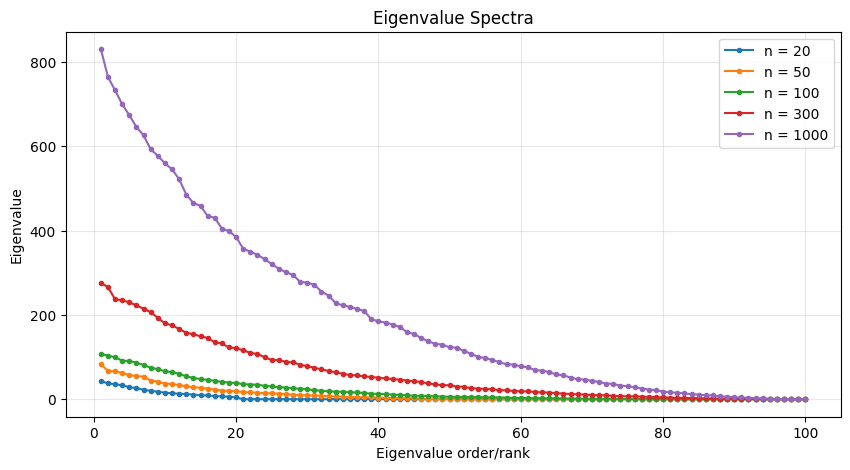

In [12]:
# Answer here

# Generate samples for each given number of samples N

samples = [generate_data(n, cov_true, np.zeros(D)) for n in Ns]
cov_matrices = [estimate_covariance(X) for X in samples]
eigenvalues = [np.linalg.eigvalsh(m) for m in cov_matrices] # shape of eigenvalues (D, len(Ns)), here being 100 values for each n in Ns
eigenvalues_sorted = [np.sort(values)[::-1]for values in eigenvalues] # [::-1] grabs array in reverse (descending) order


# Plotting eigenvalue spectra
ranks = range(1, D+1) # generate x-axis values

plt.figure(figsize=(10, 5))

for n, values_sorted in zip(Ns, eigenvalues_sorted):
    plt.plot(ranks, values_sorted, marker=".", label=f"n = {n}")

plt.xlabel("Eigenvalue order/rank")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalue Spectra")
plt.grid(True, alpha=0.3)
plt.legend()


# X_n = [generate_data(n, cov_true, np.zeros(D)) for n in Ns]
# cov_est = [estimate_covariance(X_n[i]) for i, _ in enumerate(Ns)]
# evalues = [np.linalg.eig(cov_est[i])[0] for i, _ in enumerate(Ns)]
# evalues_sorted = np.sort(evalues)
# print(evalues)
# # print(evalues_sorted)

# for n in Ns:
#     X_n = generate_data(n, cov_true, np.zeros(D))
#     cov_est = estimate_covariance(X_n)
#     evalues, _ = np.linalg.eig(cov_est)
#     print(evalues)
# # evalues_sorted = np.sort(evalues)



## Exercise 5:  Improving covariance estimation with shrinkage regularization
You have observed a systematic error in the eigenvalue estimates, even for $N > D$. We can compensate by using shrinkage regularization.

To work with shrinkage regularization we can use the `shrunk_covariance()` function from the "sklearn" library. See `estimate_regularized_covariance()` that uses that regularization.

1. Estimate the empirical covariance matrix with and without regularization;
1. For the *true*, *empirical*, and *regularized* covariance matrices, compute the eigenvalue spectrum;
1. Plot the eigenvalue spectra in a single figure;
1. Compute the mean squared error (MSE) between the true and estimated covariance matrices;
1. Report your observations.

In [13]:
def estimate_regularized_covariance(X, shrink_param=0.3):
    cov = np.cov(X.T)
    regularized_cov = shrunk_covariance(cov, shrink_param)
    return regularized_cov

In [14]:
np.random.seed(42) # ensures replicable results
N = 120
cov_true = generate_covariance(D)
X = generate_data(N, cov_true, np.zeros(D))

In [15]:
# Answer here